In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("steam_sample_20.csv")
df.head()

,app_id,name,type,release_date,price,genres,developers,publishers,pc_minimum,pc_recommended,pc_min_storage_gb,pc_rec_storage_gb,has_pc_minimum,has_pc_recommended
0,570,Dota 2,game,"Jul 9, 2013",NaN,"['Action', 'Strategy', 'Free To Play']",['Valve'],['Valve'],"{'OS': 'Windows 7 or newer', 'Processor': 'Dua...",{},4.0,NaN,True,False
1,730,Counter-Strike 2,game,"21 Aug, 2012",NaN,"['Action', 'Free To Play']",['Valve'],['Valve'],"{'OS': 'Windows® 10', 'Processor': '4 hardware...",{},8.0,NaN,True,False
2,620,Portal 2,game,"Apr 18, 2011",$9.99,"['Action', 'Adventure']",['Valve'],['Valve'],"{'OS': 'Windows 7 / Vista / XP', 'Processor': ...",{},2.0,NaN,True,False
3,1091500,Cyberpunk 2077,game,"9 Dec, 2020","R$ 199,90",['RPG'],['CD PROJEKT RED'],['CD PROJEKT RED'],"{'OS': '64-bit Windows 10', 'Processor': 'Core...","{'OS': '64-bit Windows 10', 'Processor': 'Core...",12.0,16.0,True,True
4,1245620,ELDEN RING,game,"Feb 24, 2022",$59.99,"['Action', 'RPG']","['FromSoftware, Inc.']","['FromSoftware, Inc.', 'Bandai Namco Entertain...","{'OS': 'Windows 10', 'Processor': 'INTEL CORE ...","{'OS': 'Windows 10/11', 'Processor': 'INTEL CO...",12.0,16.0,True,True


In [3]:
df.shape
df.info()
df[["name", "release_date", "pc_min_storage_gb", "pc_rec_storage_gb"]]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   app_id              5 non-null      int64  
 1   name                5 non-null      object 
 2   type                5 non-null      object 
 3   release_date        5 non-null      object 
 4   price               3 non-null      object 
 5   genres              5 non-null      object 
 6   developers          5 non-null      object 
 7   publishers          5 non-null      object 
 8   pc_minimum          5 non-null      object 
 9   pc_recommended      5 non-null      object 
 10  pc_min_storage_gb   5 non-null      float64
 11  pc_rec_storage_gb   2 non-null      float64
 12  has_pc_minimum      5 non-null      bool   
 13  has_pc_recommended  5 non-null      bool   
dtypes: bool(2), float64(2), int64(1), object(9)
memory usage: 622.0+ bytes


,name,release_date,pc_min_storage_gb,pc_rec_storage_gb
0,Dota 2,"Jul 9, 2013",4.0,NaN
1,Counter-Strike 2,"21 Aug, 2012",8.0,NaN
2,Portal 2,"Apr 18, 2011",2.0,NaN
3,Cyberpunk 2077,"9 Dec, 2020",12.0,16.0
4,ELDEN RING,"Feb 24, 2022",12.0,16.0


In [9]:
df["year"] = pd.to_datetime(
    df["release_date"],
    errors="coerce",
    infer_datetime_format=True
).dt.year
df[["name", "release_date", "year"]]

/var/folders/3x/pswb2gc16dj3h0v43n8_d6kw0000gn/T/ipykernel_58807/3362039429.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df["year"] = pd.to_datetime(


,name,release_date,year
0,Dota 2,"Jul 9, 2013",2013.0
1,Counter-Strike 2,"21 Aug, 2012",NaN
2,Portal 2,"Apr 18, 2011",2011.0
3,Cyberpunk 2077,"9 Dec, 2020",NaN
4,ELDEN RING,"Feb 24, 2022",2022.0


In [10]:
df[["year", "pc_min_storage_gb", "pc_rec_storage_gb"]].isna().mean()

year                 0.4
pc_min_storage_gb    0.0
pc_rec_storage_gb    0.6
dtype: float64

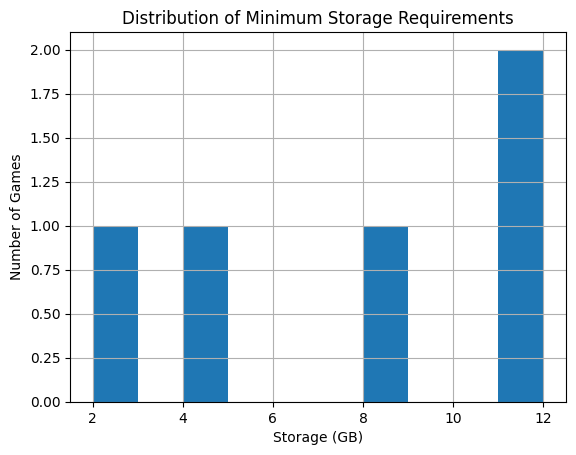

In [ ]:
df["pc_min_storage_gb"].describe()
df["pc_min_storage_gb"].hist()
plt.title("Distribution of Minimum Storage Requirements")
plt.xlabel("Storage (GB)")
plt.ylabel("Number of Games")
plt.show()


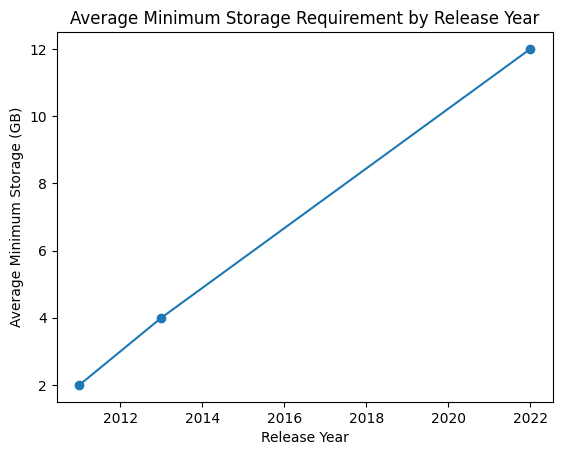

In [12]:
yearly_storage = df.groupby("year")["pc_min_storage_gb"].mean()

yearly_storage.plot(marker="o")
plt.title("Average Minimum Storage Requirement by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Average Minimum Storage (GB)")
plt.show()

In [13]:
import ast

df["genres_list"] = df["genres"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

genre_df = df.explode("genres_list")

genre_df.groupby("genres_list")["pc_min_storage_gb"].mean().sort_values(ascending=False)

genres_list
RPG             12.0
Action           6.5
Free To Play     6.0
Strategy         4.0
Adventure        2.0
Name: pc_min_storage_gb, dtype: float64